# URLS

In [1]:
# install.packages("here")  # solo la primera vez
library(here)

root <- here()
# dataset <- fread(file.path(path_base, "competencia_01_crudo.csv"))
list.files(root)
dataset_folder <- file.path(root, "DATA", "DATASETS")
exp_folder <- file.path(root, "DATA", "EXP")

dataset_url <- file.path(dataset_folder,"competencia_01_crudo.csv")

here() starts at /home/marco/code/DMEyF/dmeyf2026



[1] "arboles"                   "CazaTalentos"             
 [3] "DATA"                      "DiccionarioDatos_2026.ods"
 [5] "ensembles"                 "funciones"                
 [7] "git-zero-to-hero"          "mis_pruebas"              
 [9] "monday"                    "zero2hero"

# Generacion clase ternaria

In [2]:
require( "data.table" )

# leo el dataset
# dataset <- fread("/content/datasets/competencia_01_crudo.csv" )
dataset <- fread(dataset_url)

# calculo el periodo0 consecutivo
dsimple <- dataset[, list(
    "pos" = .I,
    numero_de_cliente,
    periodo0 = as.integer(foto_mes/100)*12 +  foto_mes%%100 ) ]


# ordeno
setorder( dsimple, numero_de_cliente, periodo0 )

# calculo topes
periodo_ultimo <- dsimple[, max(periodo0) ]
periodo_anteultimo <- periodo_ultimo - 1


# calculo los leads de orden 1 y 2
dsimple[, c("periodo1", "periodo2") :=
    shift(periodo0, n=1:2, fill=NA, type="lead"),  numero_de_cliente ]

# assign most common class values = "CONTINUA"
dsimple[ periodo0 < periodo_anteultimo, clase_ternaria := "CONTINUA" ]

# calculo BAJA+1
dsimple[ periodo0 < periodo_ultimo &
    ( is.na(periodo1) | periodo0 + 1 < periodo1 ),
    clase_ternaria := "BAJA+1" ]

# calculo BAJA+2
dsimple[ periodo0 < periodo_anteultimo & (periodo0+1 == periodo1 )
    & ( is.na(periodo2) | periodo0 + 2 < periodo2 ),
    clase_ternaria := "BAJA+2" ]


# pego el resultado en el dataset original y grabo
setorder( dsimple, pos )
dataset[, clase_ternaria := dsimple$clase_ternaria ]

fwrite( dataset,
    # file =  "/content/datasets/competencia_01.csv.gz",
    file = file.path(dataset_folder,"competencia_01.csv.gz"),
    sep = ","
)

Loading required package: data.table



In [3]:
setorder( dataset, foto_mes, clase_ternaria, numero_de_cliente)
dataset[, .N, list(foto_mes, clase_ternaria)]

foto_mes,clase_ternaria,N
<int>,<chr>,<int>
202103,BAJA+1,1019
202103,BAJA+2,960
202103,CONTINUA,160921
202104,BAJA+1,964
202104,BAJA+2,1139
202104,CONTINUA,161181
202105,BAJA+1,1143
202105,BAJA+2,870
202105,CONTINUA,161755


# Funciones

In [4]:
particionar <- function(data, division, agrupa= "", campo= "fold", start= 1, seed= NA) {
  if (!is.na(seed)) set.seed(seed, "L'Ecuyer-CMRG")

  bloque <- unlist(mapply(
    function(x, y) {rep(y, x)},division, seq(from= start, length.out= length(division))))

  data[, (campo) := sample(rep(bloque,ceiling(.N / length(bloque))))[1:.N],by= agrupa]
}

In [5]:
# iniciliazo el dataset de realidad, para medir ganancia
realidad_inicializar <- function( pfuture, pparam) {

  # datos para verificar la ganancia
  drealidad <- pfuture[, list(numero_de_cliente, foto_mes, clase_ternaria)]

  particionar(drealidad,
    division= c(3, 7),
    agrupa= "clase_ternaria",
    seed= PARAM$semilla_kaggle
  )

  return( drealidad )
}

In [6]:

realidad_evaluar <- function( prealidad, pprediccion) {

  prealidad[ pprediccion,
    on= c("numero_de_cliente", "foto_mes"),
    predicted:= i.Predicted
  ]

  tbl <- prealidad[, list("qty"=.N), list(fold, predicted, clase_ternaria)]

  res <- list()
  res$public  <- tbl[fold==1 & predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]/0.3
  res$private <- tbl[fold==2 & predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]/0.7
  res$total <- tbl[predicted==1L, sum(qty*ifelse(clase_ternaria=="BAJA+2", 1072500, -27500))]

  prealidad[, predicted:=NULL]
  return( res )
}

# Librerias

In [7]:
# cargo las librerias que necesito
require("data.table")
require("parallel")

if(!require("R.utils")) install.packages("R.utils")
require("R.utils")

if( !require("primes") ) install.packages("primes")
require("primes")

if( !require("utils") ) install.packages("utils")
require("utils")

if( !require("rlist") ) install.packages("rlist")
require("rlist")

if( !require("yaml")) install.packages("yaml")
require("yaml")

if( !require("lightgbm") ) install.packages("lightgbm")
require("lightgbm")

if( !require("DiceKriging") ) install.packages("DiceKriging")
require("DiceKriging")

if( !require("mlrMBO") ) install.packages("mlrMBO")
require("mlrMBO")

Loading required package: parallel

Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, warnings


Loading required package: primes

Loading required package: rlist

Warning message:
“package ‘

# Parametros

In [8]:
PARAM <- list()
PARAM$experimento <- 4942
PARAM$semilla_primigenia <- 240707

In [9]:
# training y future
PARAM$train <- c(202104)
PARAM$train_final <- c(202104)
PARAM$future <- c(202106)
PARAM$semilla_kaggle <- 314159
PARAM$cortes <- seq(4000, 19000, by= 500)

In [10]:
# un undersampling de 0.1  toma solo el 10% de los CONTINUA
# undersampling de 1.0  implica tomar TODOS los datos

PARAM$trainingstrategy$undersampling <- 0.1

In [11]:
# Parametros LightGBM

PARAM$hyperparametertuning$xval_folds <- 5

# parametros fijos del LightGBM que se pisaran con la parte variable de la BO
PARAM$lgbm$param_fijos <-  list(
  boosting= "gbdt", # puede ir  dart  , ni pruebe random_forest
  objective= "binary",
  metric= "average_precision",
  feature_pre_filter= FALSE,
  first_metric_only= FALSE,
  boost_from_average= TRUE,
  force_row_wise= TRUE,
  deterministic= TRUE,
  verbosity= -100,

  seed= PARAM$semilla_primigenia,

  max_depth= -1L,
  min_gain_to_split= 0,
  lambda_l1= 0.0,
  lambda_l2= 0.0,
  max_bin= 31L,

  bagging_fraction= 1.0,
  pos_bagging_fraction= 1.0,
  neg_bagging_fraction= 1.0,
  is_unbalance= FALSE,
  scale_pos_weight= 1.0,

  drop_rate= 0.1,
  max_drop= 50,
  skip_drop= 0.5,

  extra_trees= FALSE,

  early_stopping= 0,
  # min_data_in_leaf= 184,     # fijo, esto es FUNDAMENTAL
  min_data_in_leaf= 1840,     # fijo, esto es FUNDAMENTAL
  feature_fraction= 0.5707911,  # fijo
  learning_rate= 0.0020182,    # fijo

  num_iterations= 2505,     # se modificara
  num_leaves= 61,          # se modificara
  min_sum_hessian_in_leaf= 0.0067274  # se modificara
)


In [12]:
# lectura del dataset
# dataset <- fread("/content/datasets/competencia_01.csv.gz", stringsAsFactors= TRUE)
dataset <- fread(file.path(dataset_folder,"competencia_01.csv.gz"), stringsAsFactors= TRUE)

In [13]:
# clase01
dataset[, clase01 := ifelse(clase_ternaria %in% c("BAJA+1", "BAJA+2"), 1L, 0L)]

In [14]:
dataset_train <- dataset[foto_mes %in% PARAM$train_final]
dataset_train[,.N, list(foto_mes, clase_ternaria)]

foto_mes,clase_ternaria,N
<int>,<fct>,<int>
202104,CONTINUA,161181
202104,BAJA+2,1139
202104,BAJA+1,964


In [15]:
PARAM$lgbm$param_fijos




$boosting
[1] "gbdt"

$objective
[1] "binary"

$metric
[1] "average_precision"

$feature_pre_filter
[1] FALSE

$first_metric_only
[1] FALSE

$boost_from_average
[1] TRUE

$force_row_wise
[1] TRUE

$deterministic
[1] TRUE

$verbosity
[1] -100

$seed
[1] 240707

$max_depth
[1] -1

$min_gain_to_split
[1] 0

$lambda_l1
[1] 0

$lambda_l2
[1] 0

$max_bin
[1] 31

$bagging_fraction
[1] 1

$pos_bagging_fraction
[1] 1

$neg_bagging_fraction
[1] 1

$is_unbalance
[1] FALSE

$scale_pos_weight
[1] 1

$drop_rate
[1] 0.1

$max_drop
[1] 50

$skip_drop
[1] 0.5

$extra_trees
[1] FALSE

$early_stopping
[1] 0

$min_data_in_leaf
[1] 1840

$feature_fraction
[1] 0.5707911

$learning_rate
[1] 0.0020182

$num_iterations
[1] 2505

$num_leaves
[1] 61

$min_sum_hessian_in_leaf
[1] 0.0067274

In [16]:
# aplico el modelo a los datos sin clase
dfuture <- dataset[foto_mes %in% PARAM$future]

In [17]:
PARAM$future

[1] 202106

In [18]:
campos_buenos1 <- setdiff(
  colnames(dataset),
  c("clase_ternaria", "clase01", "azar", "training")
)
campos_buenos2 <- setdiff(
  colnames(dataset),
  c(
    "clase_ternaria", "clase01", "azar", "training",
    "cprestamos_personales", "mprestamos_personales"
  )
)

In [16]:
# Entreno el modelo sobre todo el periodo

dtrain_final1 <- lgb.Dataset(
  data= data.matrix(dataset_train[, campos_buenos1, with= FALSE]),
  label= dataset_train[, clase01]
)

modelo_final1 <- lgb.train(
  data= dtrain_final1,
  param= PARAM$lgbm$param_fijos
)

In [19]:
# Entreno el modelo sobre todo el periodo

dtrain_final2 <- lgb.Dataset(
  data= data.matrix(dataset_train[, campos_buenos2, with= FALSE]),
  label= dataset_train[, clase01]
)

modelo_final2 <- lgb.train(
  data= dtrain_final2,
  param= PARAM$lgbm$param_fijos
)

# Evaluacion 1
    removemos columnas "clase_ternaria", "clase01", "azar", "training"
    Los Hiperparametros fueron encotrados con BO usando esta configuracion de columnas de partida en el dataset
    

In [28]:
campos_buenos1

[1] "numero_de_cliente"                   
  [2] "foto_mes"                            
  [3] "active_quarter"                      
  [4] "cliente_vip"                         
  [5] "internet"                            
  [6] "cliente_edad"                        
  [7] "cliente_antiguedad"                  
  [8] "mrentabilidad"                       
  [9] "mrentabilidad_annual"                
 [10] "mcomisiones"                         
 [11] "mactivos_margen"                     
 [12] "mpasivos_margen"                     
 [13] "cproductos"                          
 [14] "tcuentas"                            
 [15] "ccuenta_corriente"                   
 [16] "mcuenta_corriente_adicional"         
 [17] "mcuenta_corriente"                   
 [18] "ccaja_ahorro"                        
 [19] "mcaja_ahorro"                        
 [20] "mcaja_ahorro_adicional"              
 [21] "mcaja_ahorro_dolares"                
 [22] "cdescubierto_preacordado"            
 [23] "mcuentas_saldo"                      
 [24] "ctarjeta_debito"                     
 [25] "ctarjeta_debito_transacciones"       
 [26] "mautoservicio"                       
 [27] "ctarjeta_visa"                       
 [28] "ctarjeta_visa_transacciones"         
 [29] "mtarjeta_visa_consumo"               
 [30] "ctarjeta_master"                     
 [31] "ctarjeta_master_transacciones"       
 [32] "mtarjeta_master_consumo"             
 [33] "cprestamos_personales"               
 [34] "mprestamos_personales"               
 [35] "cprestamos_prendarios"               
 [36] "mprestamos_prendarios"               
 [37] "cprestamos_hipotecarios"             
 [38] "mprestamos_hipotecarios"             
 [39] "cplazo_fijo"                         
 [40] "mplazo_fijo_dolares"                 
 [41] "mplazo_fijo_pesos"                   
 [42] "cinversion1"                         
 [43] "minversion1_pesos"                   
 [44] "minversion1_dolares"                 
 [45] "cinversion2"                         
 [46] "minversion2"                         
 [47] "cseguro_vida"                        
 [48] "cseguro_auto"                        
 [49] "cseguro_vivienda"                    
 [50] "cseguro_accidentes_personales"       
 [51] "ccaja_seguridad"                     
 [52] "cpayroll_trx"                        
 [53] "mpayroll"                            
 [54] "mpayroll2"                           
 [55] "cpayroll2_trx"                       
 [56] "ccuenta_debitos_automaticos"         
 [57] "mcuenta_debitos_automaticos"         
 [58] "ctarjeta_visa_debitos_automaticos"   
 [59] "mttarjeta_visa_debitos_automaticos"  
 [60] "ctarjeta_master_debitos_automaticos" 
 [61] "mttarjeta_master_debitos_automaticos"
 [62] "cpagodeservicios"                    
 [63] "mpagodeservicios"                    
 [64] "cpagomiscuentas"                     
 [65] "mpagomiscuentas"                     
 [66] "ccajeros_propios_descuentos"         
 [67] "mcajeros_propios_descuentos"         
 [68] "ctarjeta_visa_descuentos"            
 [69] "mtarjeta_visa_descuentos"            
 [70] "ctarjeta_master_descuentos"          
 [71] "mtarjeta_master_descuentos"          
 [72] "ccomisiones_mantenimiento"           
 [73] "mcomisiones_mantenimiento"           
 [74] "ccomisiones_otras"                   
 [75] "mcomisiones_otras"                   
 [76] "cforex"                              
 [77] "cforex_buy"                          
 [78] "mforex_buy"                          
 [79] "cforex_sell"                         
 [80] "mforex_sell"                         
 [81] "ctransferencias_recibidas"           
 [82] "mtransferencias_recibidas"           
 [83] "ctransferencias_emitidas"            
 [84] "mtransferencias_emitidas"            
 [85] "cextraccion_autoservicio"            
 [86] "mextraccion_autoservicio"            
 [87] "ccheques_depositados"                
 [88] "mcheques_depositados"                
 [89] "ccheques_emitidos"                 

In [18]:
# hago el predict en los datos del futuro, y calculo la ganancia

# aplico el modelo a los datos nuevos
prediccion1 <- predict(
  modelo_final1,
  data.matrix(dfuture[, campos_buenos1, with= FALSE])
)


In [19]:
# calculo la ganancia en los datos ddel futuro para todos los cortes
tb_prediccion1 <- dfuture[, list(numero_de_cliente, foto_mes,clase_ternaria)]
tb_prediccion1[, prob := prediccion1 ]
tb_prediccion1[, gan := ifelse(clase_ternaria == "BAJA+2", 1072500, -27500)]

# lgb.save(modelo_final, "modelo.txt" )
# Dibujo la curva de ganancia acumulada
setorder(tb_prediccion1, -prob)
tb_prediccion1[, ganancia_acumulada := cumsum(gan)]
tb_prediccion1[, pos := sequence(.N)]

tb_prediccion1|> head()

numero_de_cliente,foto_mes,clase_ternaria,prob,gan,ganancia_acumulada,pos
<dbl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<int>
70114873,202106,BAJA+1,0.8874342,-27500,-27500,1
52633105,202106,CONTINUA,0.8758596,-27500,-55000,2
34512329,202106,CONTINUA,0.8705225,-27500,-82500,3
74768609,202106,BAJA+1,0.8424208,-27500,-110000,4
28793962,202106,CONTINUA,0.8418961,-27500,-137500,5
31050334,202106,BAJA+2,0.8327058,1072500,935000,6


In [25]:
for (envios in PARAM$cortes) {
  ganancia1 <- tb_prediccion1[1:envios, sum(gan)]
  cat( envios, "\t", ganancia1, "\n")
}

4000 	 255200000 
4500 	 283250000 
5000 	 293700000 
5500 	 315150000 
6000 	 322300000 
6500 	 331650000 
7000 	 335500000 
7500 	 344850000 
8000 	 350900000 
8500 	 352550000 
9000 	 355300000 
9500 	 359150000 
10000 	 359700000 
10500 	 364650000 
11000 	 364100000 
11500 	 363550000 
12000 	 361900000 
12500 	 371250000 
13000 	 372900000 
13500 	 381150000 
14000 	 380600000 
14500 	 377850000 
15000 	 378400000 
15500 	 380050000 
16000 	 376200000 
16500 	 372350000 
17000 	 364100000 
17500 	 356950000 
18000 	 356400000 
18500 	 353650000 
19000 	 346500000 


Loading required package: ggplot2



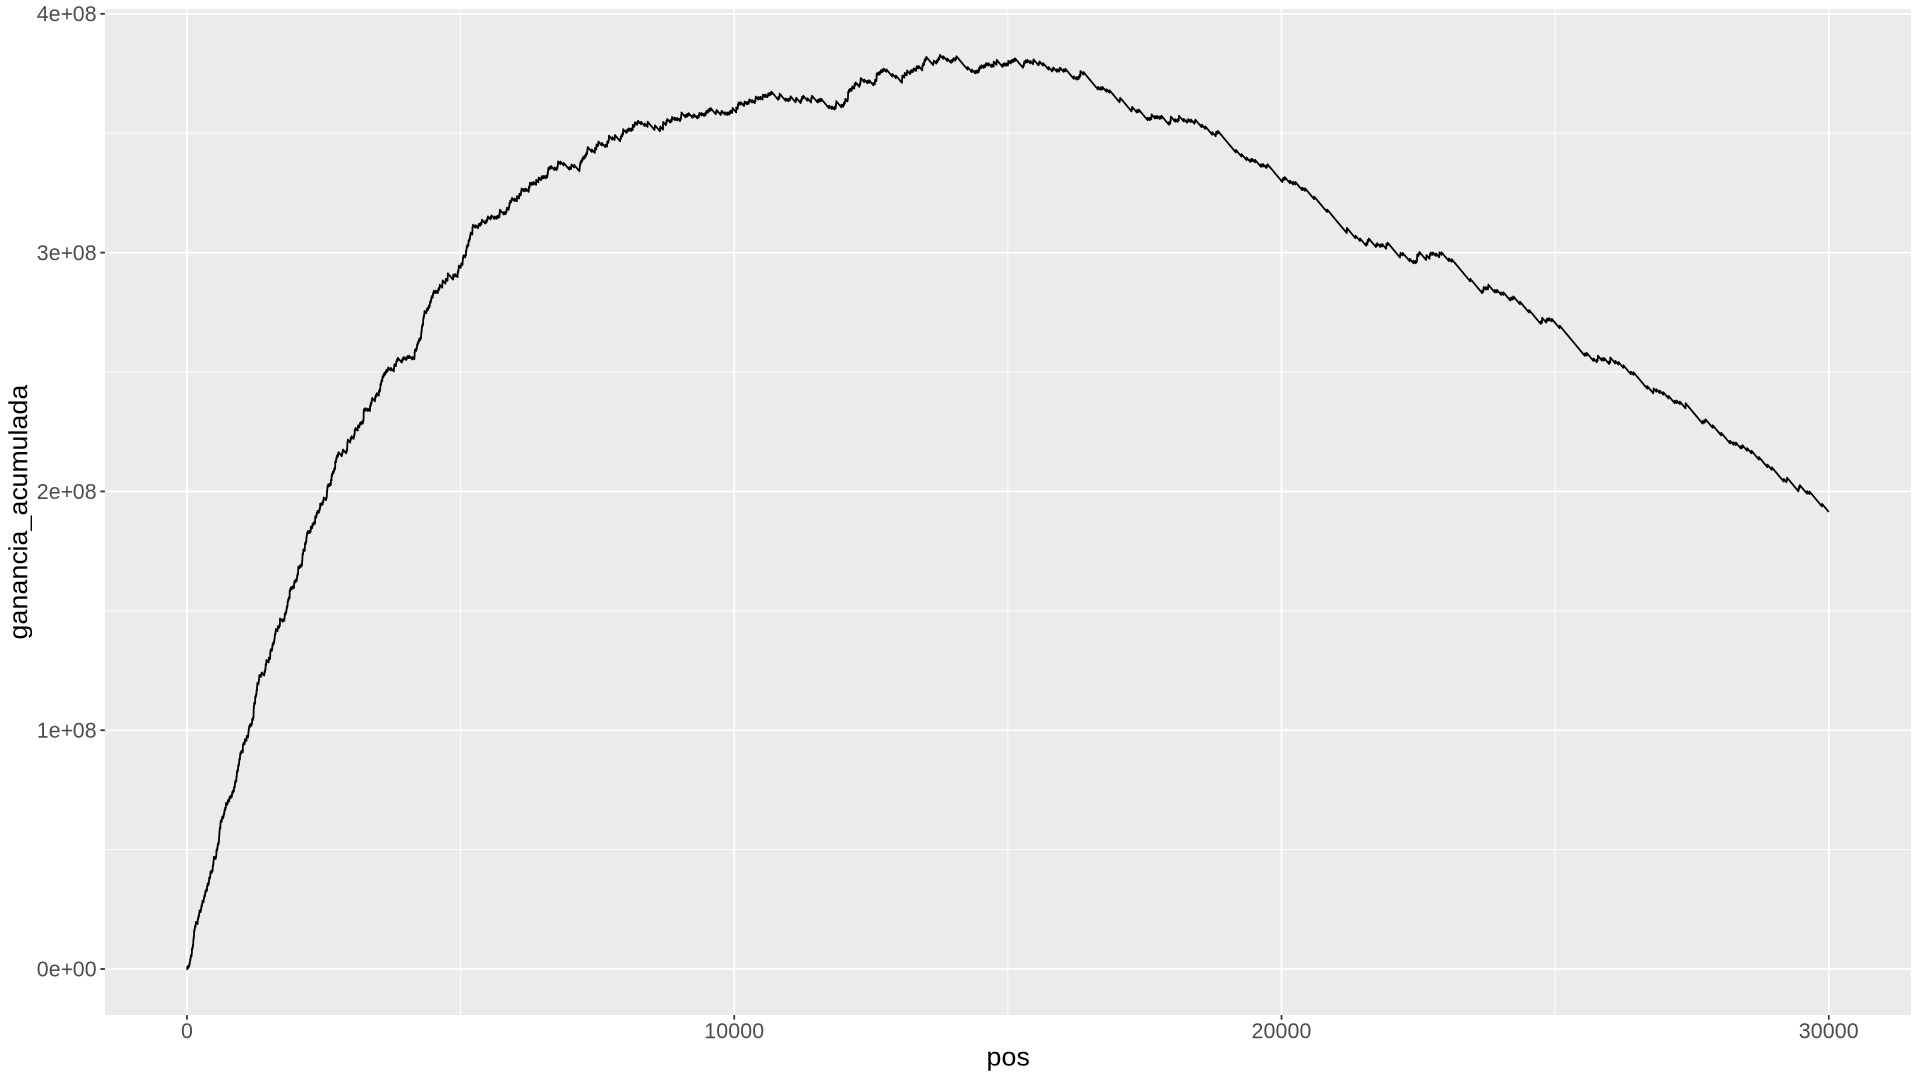

In [20]:
require("ggplot2")
# defino hasta donde muestra el grafico
amostrar <- 30000
# observamos la curva de ganancia
gra <- ggplot(
           data= tb_prediccion1[pos <= amostrar],
           aes( x= pos, y= ganancia_acumulada)
             ) + geom_line()

gra <- gra + theme(text = element_text(size = 16))

options(repr.plot.width=16, repr.plot.height=9)
print( gra )

In [25]:
# inicilizo el dataset  drealidad
drealidad <- realidad_inicializar( dfuture, PARAM)


In [30]:
PARAM$cortes

[1]  4000  4500  5000  5500  6000  6500  7000  7500  8000  8500  9000  9500
[13] 10000 10500 11000 11500 12000 12500 13000 13500 14000 14500 15000 15500
[25] 16000 16500 17000 17500 18000 18500 19000

In [32]:
tb_prediccion1


numero_de_cliente,foto_mes,clase_ternaria,prob,gan,ganancia_acumulada,pos
<dbl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<int>
70114873,202106,BAJA+1,0.8874342,-27500,-27500,1
52633105,202106,CONTINUA,0.8758596,-27500,-55000,2
34512329,202106,CONTINUA,0.8705225,-27500,-82500,3
74768609,202106,BAJA+1,0.8424208,-27500,-110000,4
28793962,202106,CONTINUA,0.8418961,-27500,-137500,5
31050334,202106,BAJA+2,0.8327058,1072500,935000,6
59651944,202106,CONTINUA,0.8261577,-27500,907500,7
49746112,202106,BAJA+1,0.8260881,-27500,880000,8
31064888,202106,BAJA+1,0.8238321,-27500,852500,9


In [38]:
# genero archivos con los  "envios" mejores

# ordeno por probabilidad descendente
setorder(tb_prediccion1, -prob)

for (envios in PARAM$cortes) {

  tb_prediccion1[, Predicted := 0L] # seteo inicial a 0
  tb_prediccion1[1:envios, Predicted := 1L] # marco los primeros

  res <- realidad_evaluar( drealidad, tb_prediccion1)

  options(scipen = 999)
  cat( "Envios=", envios, "\t",
    " TOTAL=", res$total,
    "  Public=", res$public,
    " Private=", res$private,
    "\n",
    sep= ""
  )

}

Envios=4000	 TOTAL=255200000  Public=242275000 Private=260739286
Envios=4500	 TOTAL=283250000  Public=278758333 Private=285175000
Envios=5000	 TOTAL=293700000  Public=279766667 Private=299671429
Envios=5500	 TOTAL=315150000  Public=309466667 Private=317585714
Envios=6000	 TOTAL=322300000  Public=305983333 Private=329292857
Envios=6500	 TOTAL=331650000  Public=308000000 Private=341785714
Envios=7000	 TOTAL=335500000  Public=306166667 Private=348071429
Envios=7500	 TOTAL=344850000  Public=322758333 Private=354317857
Envios=8000	 TOTAL=350900000  Public=327525000 Private=360917857
Envios=8500	 TOTAL=352550000  Public=328625000 Private=362803571
Envios=9000	 TOTAL=355300000  Public=340266667 Private=361742857
Envios=9500	 TOTAL=359150000  Public=348241667 Private=363825000
Envios=10000	 TOTAL=359700000  Public=349891667 Private=363903571
Envios=10500	 TOTAL=364650000  Public=352550000 Private=369835714
Envios=11000	 TOTAL=364100000  Public=355941667 Private=367596429
Envios=11500	 TOTAL=36

# Evaluacion 2
        Removemos "clase_ternaria", "clase01", "azar", "training",    "cprestamos_personales", "mprestamos_personales"
        Los Hiperparametros fueron encotrados con BO con "cprestamos_personales", "mprestamos_personales" presentes, no se habían removido.

In [27]:
campos_buenos2

[1] "numero_de_cliente"                   
  [2] "foto_mes"                            
  [3] "active_quarter"                      
  [4] "cliente_vip"                         
  [5] "internet"                            
  [6] "cliente_edad"                        
  [7] "cliente_antiguedad"                  
  [8] "mrentabilidad"                       
  [9] "mrentabilidad_annual"                
 [10] "mcomisiones"                         
 [11] "mactivos_margen"                     
 [12] "mpasivos_margen"                     
 [13] "cproductos"                          
 [14] "tcuentas"                            
 [15] "ccuenta_corriente"                   
 [16] "mcuenta_corriente_adicional"         
 [17] "mcuenta_corriente"                   
 [18] "ccaja_ahorro"                        
 [19] "mcaja_ahorro"                        
 [20] "mcaja_ahorro_adicional"              
 [21] "mcaja_ahorro_dolares"                
 [22] "cdescubierto_preacordado"            
 [23] "mcuentas_saldo"                      
 [24] "ctarjeta_debito"                     
 [25] "ctarjeta_debito_transacciones"       
 [26] "mautoservicio"                       
 [27] "ctarjeta_visa"                       
 [28] "ctarjeta_visa_transacciones"         
 [29] "mtarjeta_visa_consumo"               
 [30] "ctarjeta_master"                     
 [31] "ctarjeta_master_transacciones"       
 [32] "mtarjeta_master_consumo"             
 [33] "cprestamos_prendarios"               
 [34] "mprestamos_prendarios"               
 [35] "cprestamos_hipotecarios"             
 [36] "mprestamos_hipotecarios"             
 [37] "cplazo_fijo"                         
 [38] "mplazo_fijo_dolares"                 
 [39] "mplazo_fijo_pesos"                   
 [40] "cinversion1"                         
 [41] "minversion1_pesos"                   
 [42] "minversion1_dolares"                 
 [43] "cinversion2"                         
 [44] "minversion2"                         
 [45] "cseguro_vida"                        
 [46] "cseguro_auto"                        
 [47] "cseguro_vivienda"                    
 [48] "cseguro_accidentes_personales"       
 [49] "ccaja_seguridad"                     
 [50] "cpayroll_trx"                        
 [51] "mpayroll"                            
 [52] "mpayroll2"                           
 [53] "cpayroll2_trx"                       
 [54] "ccuenta_debitos_automaticos"         
 [55] "mcuenta_debitos_automaticos"         
 [56] "ctarjeta_visa_debitos_automaticos"   
 [57] "mttarjeta_visa_debitos_automaticos"  
 [58] "ctarjeta_master_debitos_automaticos" 
 [59] "mttarjeta_master_debitos_automaticos"
 [60] "cpagodeservicios"                    
 [61] "mpagodeservicios"                    
 [62] "cpagomiscuentas"                     
 [63] "mpagomiscuentas"                     
 [64] "ccajeros_propios_descuentos"         
 [65] "mcajeros_propios_descuentos"         
 [66] "ctarjeta_visa_descuentos"            
 [67] "mtarjeta_visa_descuentos"            
 [68] "ctarjeta_master_descuentos"          
 [69] "mtarjeta_master_descuentos"          
 [70] "ccomisiones_mantenimiento"           
 [71] "mcomisiones_mantenimiento"           
 [72] "ccomisiones_otras"                   
 [73] "mcomisiones_otras"                   
 [74] "cforex"                              
 [75] "cforex_buy"                          
 [76] "mforex_buy"                          
 [77] "cforex_sell"                         
 [78] "mforex_sell"                         
 [79] "ctransferencias_recibidas"           
 [80] "mtransferencias_recibidas"           
 [81] "ctransferencias_emitidas"            
 [82] "mtransferencias_emitidas"            
 [83] "cextraccion_autoservicio"            
 [84] "mextraccion_autoservicio"            
 [85] "ccheques_depositados"                
 [86] "mcheques_depositados"                
 [87] "ccheques_emitidos"                   
 [88] "mcheques_emitidos"                   
 [89] "ccheques_depositados_rechazados"   

In [31]:
diferencias1 <- setdiff(campos_buenos1, campos_buenos2)
diferencias1

[1] "cprestamos_personales" "mprestamos_personales"

In [20]:
# hago el predict en los datos del futuro, y calculo la ganancia

# aplico el modelo a los datos nuevos
prediccion2 <- predict(
  modelo_final2,
  data.matrix(dfuture[, campos_buenos2, with= FALSE])
)


In [21]:
# calculo la ganancia en los datos ddel futuro para todos los cortes
tb_prediccion2 <- dfuture[, list(numero_de_cliente, foto_mes,clase_ternaria)]
tb_prediccion2[, prob := prediccion2 ]
tb_prediccion2[, gan := ifelse(clase_ternaria == "BAJA+2", 1072500, -27500)]

# lgb.save(modelo_final, "modelo.txt" )
# Dibujo la curva de ganancia acumulada
setorder(tb_prediccion2, -prob)
tb_prediccion2[, ganancia_acumulada := cumsum(gan)]
tb_prediccion2[, pos := sequence(.N)]

tb_prediccion2|> head()

numero_de_cliente,foto_mes,clase_ternaria,prob,gan,ganancia_acumulada,pos
<dbl>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<int>
52633105,202106,CONTINUA,0.8602229,-27500,-27500,1
74768609,202106,BAJA+1,0.8372686,-27500,-55000,2
70114873,202106,BAJA+1,0.8353062,-27500,-82500,3
59651944,202106,CONTINUA,0.8296807,-27500,-110000,4
34512329,202106,CONTINUA,0.8214410,-27500,-137500,5
65835641,202106,CONTINUA,0.8135298,-27500,-165000,6


In [22]:

for (envios in PARAM$cortes) {
  ganancia2 <- tb_prediccion2[1:envios, sum(gan)]
  cat( envios, "\t", ganancia2, "\n")}

4000 	 314600000 
4500 	 332750000 
5000 	 345400000 
5500 	 358050000 
6000 	 371800000 
6500 	 389950000 
7000 	 392700000 
7500 	 396550000 
8000 	 409200000 
8500 	 418550000 
9000 	 420200000 
9500 	 430650000 
10000 	 438900000 
10500 	 447150000 
11000 	 442200000 
11500 	 443850000 
12000 	 445500000 
12500 	 451550000 
13000 	 4.51e+08 
13500 	 442750000 
14000 	 442200000 
14500 	 441650000 
15000 	 438900000 
15500 	 432850000 
16000 	 426800000 
16500 	 424050000 
17000 	 422400000 
17500 	 420750000 
18000 	 411400000 
18500 	 406450000 
19000 	 3.96e+08 


Loading required package: ggplot2



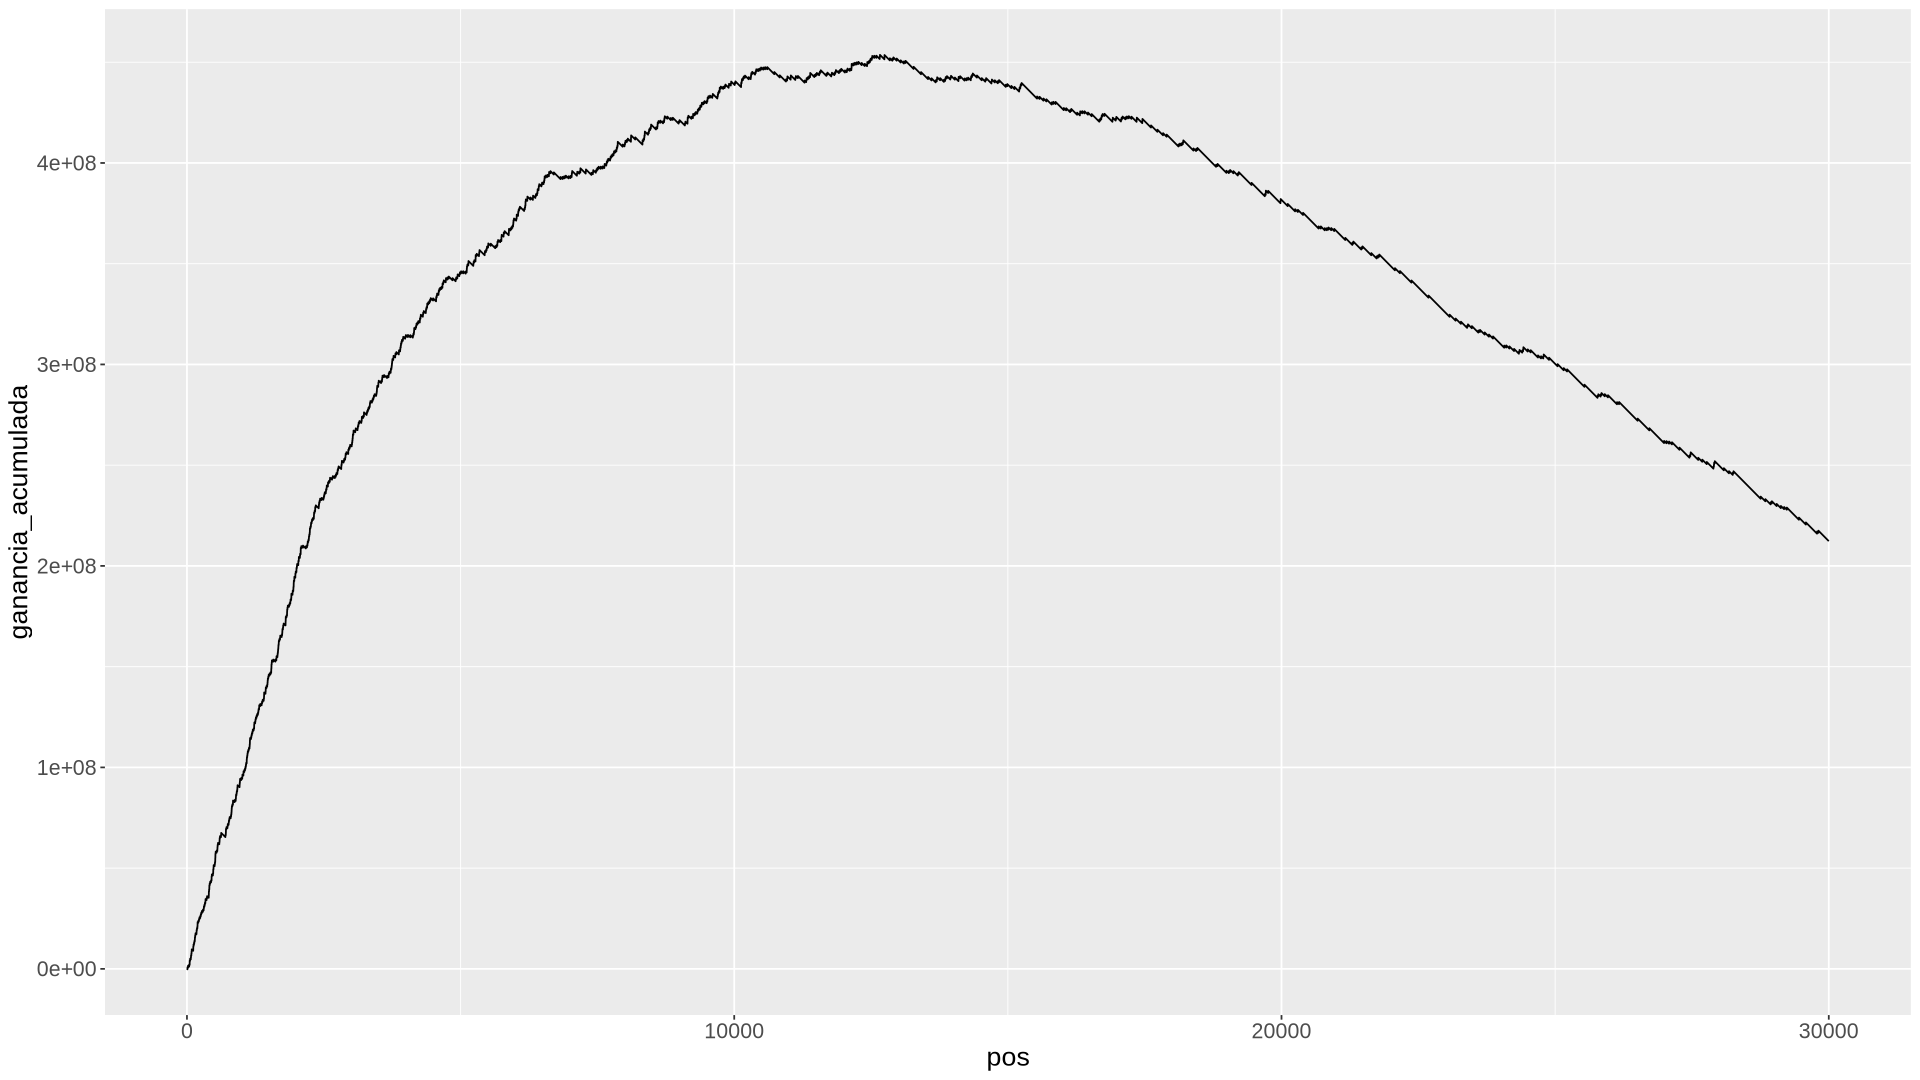

In [23]:
require("ggplot2")
# defino hasta donde muestra el grafico
amostrar <- 30000
# observamos la curva de ganancia
gra <- ggplot(
           data= tb_prediccion2[pos <= amostrar],
           aes( x= pos, y= ganancia_acumulada)
             ) + geom_line()

gra <- gra + theme(text = element_text(size = 16))

options(repr.plot.width=16, repr.plot.height=9)
print( gra )

In [26]:
# genero archivos con los  "envios" mejores

# ordeno por probabilidad descendente
setorder(tb_prediccion2, -prob)

for (envios in PARAM$cortes) {

  tb_prediccion2[, Predicted := 0L] # seteo inicial a 0
  tb_prediccion2[1:envios, Predicted := 1L] # marco los primeros

  res <- realidad_evaluar( drealidad, tb_prediccion2)

  options(scipen = 999)
  cat( "Envios=", envios, "\t",
    " TOTAL=", res$total,
    "  Public=", res$public,
    " Private=", res$private,
    "\n",
    sep= ""
  )

}

Envios=4000	 TOTAL=314600000  Public=315333333 Private=314285714
Envios=4500	 TOTAL=332750000  Public=338616667 Private=330235714
Envios=5000	 TOTAL=345400000  Public=357225000 Private=340332143
Envios=5500	 TOTAL=358050000  Public=387291667 Private=345517857
Envios=6000	 TOTAL=371800000  Public=402233333 Private=358757143
Envios=6500	 TOTAL=389950000  Public=416991667 Private=378360714
Envios=7000	 TOTAL=392700000  Public=420475000 Private=380796429
Envios=7500	 TOTAL=396550000  Public=420750000 Private=386178571
Envios=8000	 TOTAL=409200000  Public=421850000 Private=403778571
Envios=8500	 TOTAL=418550000  Public=423500000 Private=416428571
Envios=9000	 TOTAL=420200000  Public=440916667 Private=411321429
Envios=9500	 TOTAL=430650000  Public=449716667 Private=422478571
Envios=10000	 TOTAL=438900000  Public=461725000 Private=429117857
Envios=10500	 TOTAL=447150000  Public=465941667 Private=439096429
Envios=11000	 TOTAL=442200000  Public=455766667 Private=436385714
Envios=11500	 TOTAL=44